In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

In [7]:
def to_month_start(s: pd.Series) -> pd.Series:
    dt = pd.to_datetime(s)
    # 월 시작일로 강제 변환 (버전 호환 안전)
    return pd.to_datetime(dt.dt.year.astype(str) + "-" +
                          dt.dt.month.astype(str) + "-01")

def pick_value_col(df: pd.DataFrame) -> str:
    # 가장 흔한 value 컬럼 우선
    for c in ["value", "Value", "val", "VAL", "data", "DATA"]:
        if c in df.columns:
            return c
    # 숫자형 첫 컬럼
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        raise ValueError(f"Cannot find numeric value col. cols={df.columns.tolist()}")
    return num_cols[0]

def yoy(x: pd.Series) -> pd.Series:
    return x.pct_change(12)

def diff12(x: pd.Series) -> pd.Series:
    return x.diff(12)

def zscore(x: pd.Series) -> pd.Series:
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=0)
    if sd == 0 or np.isnan(sd):
        return x * np.nan
    return (x - mu) / sd

def mom_k(x: pd.Series, k: int) -> pd.Series:
    return x.pct_change(k)

def extract_periods(mask: np.ndarray, dates: pd.Series):
    """연속 True 구간을 (start_date, end_date) 리스트로 반환"""
    periods = []
    i = 0
    n = len(mask)
    while i < n:
        if mask[i]:
            s = i
            while i + 1 < n and mask[i + 1]:
                i += 1
            e = i
            periods.append((dates.iloc[s], dates.iloc[e]))
        i += 1
    return periods

In [8]:
BASE = "data"
pre = "data/preprocessed"
dec_path = os.path.join(BASE, "decoupling.csv")
assert os.path.exists(dec_path), f"missing: {dec_path}"

dec = pd.read_csv(dec_path)
dec["date"] = to_month_start(dec["date"])
dec = dec.sort_values("date").reset_index(drop=True)

# 전처리 파일들 로드
paths = sorted(glob.glob(os.path.join(pre, "전처리_*.csv")))
print("found preprocess files:", len(paths))
for p in paths[:5]:
    print(" -", os.path.basename(p))

series = {}
for p in paths:
    name = os.path.splitext(os.path.basename(p))[0].replace("전처리_", "")
    df = pd.read_csv(p)

    # date 컬럼 찾기
    if "date" not in df.columns:
        # 혹시 datetime 같은 이름이면 대응
        cand = [c for c in df.columns if c.lower() in ("date","datetime","time")]
        if not cand:
            raise ValueError(f"{p}: no date column. cols={df.columns.tolist()}")
        df = df.rename(columns={cand[0]:"date"})

    df["date"] = to_month_start(df["date"])
    vcol = pick_value_col(df)
    df = df[["date", vcol]].rename(columns={vcol: name})
    df = df.sort_values("date").reset_index(drop=True)

    series[name] = df

# 전처리 지표들 inner merge
macro = None
for name, df in series.items():
    macro = df.copy() if macro is None else macro.merge(df, on="date", how="inner")

# decoupling + macro merge (inner)
df = dec.merge(macro, on="date", how="inner").sort_values("date").reset_index(drop=True)

print("merged df shape:", df.shape)
print(df.columns.tolist())
df.head()

found preprocess files: 12
 - 전처리_M2.csv
 - 전처리_cpi.csv
 - 전처리_가계대출.csv
 - 전처리_기업대출.csv
 - 전처리_기준금리.csv
merged df shape: (71, 18)
['date', 'fin_index', 'real_index', 'gap', 'top_regime', 'bottom_regime', 'M2', 'cpi', '가계대출', '기업대출', '기준금리', '대출금리', '소매판매액지수', '신용스프레드', '신용카드사용액', '전산업생산지수', '코스피', '환율']


,date,fin_index,real_index,gap,top_regime,bottom_regime,M2,cpi,가계대출,기업대출,기준금리,대출금리,소매판매액지수,신용스프레드,신용카드사용액,전산업생산지수,코스피,환율
0,2008-01-01,-0.231403,1.242531,-1.473934,False,True,1105916.8,79.472,473606.9,465822.9,5.00,7.25,71.2,1.20,37047103,79.8,1624.68,943.85
1,2008-04-01,-0.324827,1.216186,-1.541013,False,True,1143956.6,80.962,485302.9,493407.0,5.00,6.91,72.3,0.93,37517521,79.9,1825.47,1003.00
2,2008-07-01,-1.038060,0.889147,-1.927208,False,True,1190474.9,82.747,498816.4,516928.7,5.00,7.12,69.8,1.03,40291279,79.2,1594.67,1012.25
3,2008-10-01,-3.450642,-0.855806,-2.594835,False,True,1237588.2,82.598,509177.8,528536.9,4.25,7.79,69.9,2.86,39319067,78.4,1113.06,1282.50
4,2009-01-01,-3.286671,-2.290712,-0.995959,False,False,1292462.7,82.450,511998.3,542479.1,2.50,5.91,69.1,3.90,35801266,73.7,1162.11,1381.50


In [9]:
cols = df.columns.tolist()

def find_col(keywords):
    for c in cols:
        lc = c.lower()
        if all(k in lc for k in keywords):
            return c
    return None

# 자동 매핑 (있으면 잡히고, 없으면 None)
MAP = {
    "M2": find_col(["m2"]),
    "BASE_RATE": find_col(["기준금리"]) or find_col(["base", "rate"]) or find_col(["policy", "rate"]),
    "SPREAD": find_col(["신용", "스프레드"]) or find_col(["spread"]),
    "FX": find_col(["환율"]) or find_col(["fx"]) or find_col(["exchange"]),
    "KOSPI": find_col(["코스피"]) or find_col(["kospi"]),
    "RETAIL": find_col(["소매"]) or find_col(["retail"]),
    "IP": find_col(["전산업", "생산"]) or find_col(["industrial", "production"]) or find_col(["ip"]),
    "CARD": find_col(["신용카드", "사용액"]) or find_col(["card"]),
}

MAP

{'M2': 'M2',
 'BASE_RATE': '기준금리',
 'SPREAD': '신용스프레드',
 'FX': '환율',
 'KOSPI': '코스피',
 'RETAIL': '소매판매액지수',
 'IP': '전산업생산지수',
 'CARD': '신용카드사용액'}

In [10]:
# 필요할 때만 수정
# 예:
# MAP["CARD"] = "신용카드사용액"
# MAP["SPREAD"] = "전처리_신용스프레드에서 들어온 실제 컬럼명"

missing = [k for k,v in MAP.items() if v is None]
print("missing keys:", missing)

# 존재하는 키만 사용하도록 체크
use_keys = [k for k,v in MAP.items() if v is not None]
print("using keys:", use_keys)

df[[ "date", "gap"] + [MAP[k] for k in use_keys]].head()

missing keys: []
using keys: ['M2', 'BASE_RATE', 'SPREAD', 'FX', 'KOSPI', 'RETAIL', 'IP', 'CARD']


,date,gap,M2,기준금리,신용스프레드,환율,코스피,소매판매액지수,전산업생산지수,신용카드사용액
0,2008-01-01,-1.473934,1105916.8,5.00,1.20,943.85,1624.68,71.2,79.8,37047103
1,2008-04-01,-1.541013,1143956.6,5.00,0.93,1003.00,1825.47,72.3,79.9,37517521
2,2008-07-01,-1.927208,1190474.9,5.00,1.03,1012.25,1594.67,69.8,79.2,40291279
3,2008-10-01,-2.594835,1237588.2,4.25,2.86,1282.50,1113.06,69.9,78.4,39319067
4,2009-01-01,-0.995959,1292462.7,2.50,3.90,1381.50,1162.11,69.1,73.7,35801266


In [11]:
feat = pd.DataFrame({"date": df["date"], "gap": df["gap"]})

def add_yoy_z(out, raw_col, out_name):
    x = df[raw_col].astype(float)
    out[out_name] = zscore(yoy(x))
    return out

def add_diff12_z(out, raw_col, out_name):
    x = df[raw_col].astype(float)
    out[out_name] = zscore(diff12(x))
    return out

# Build-up inputs
if MAP["M2"] is not None:       feat = add_yoy_z(feat, MAP["M2"], "m2_yoy_z")
if MAP["FX"] is not None:       feat = add_yoy_z(feat, MAP["FX"], "fx_yoy_z")
if MAP["KOSPI"] is not None:    feat = add_yoy_z(feat, MAP["KOSPI"], "kospi_yoy_z")
if MAP["RETAIL"] is not None:   feat = add_yoy_z(feat, MAP["RETAIL"], "retail_yoy_z")
if MAP["IP"] is not None:       feat = add_yoy_z(feat, MAP["IP"], "ip_yoy_z")
if MAP["CARD"] is not None:     feat = add_yoy_z(feat, MAP["CARD"], "card_yoy_z")

# rate/spread: 12m 변화량 z (정책/여건 변화)
if MAP["BASE_RATE"] is not None: feat = add_diff12_z(feat, MAP["BASE_RATE"], "base_rate_d12_z")
if MAP["SPREAD"] is not None:    feat = add_diff12_z(feat, MAP["SPREAD"], "spread_d12_z")

feat.tail(15)

,date,gap,m2_yoy_z,fx_yoy_z,kospi_yoy_z,retail_yoy_z,ip_yoy_z,card_yoy_z,base_rate_d12_z,spread_d12_z
56,2022-01-01,-1.691061,1.846397,0.503349,0.464013,0.232558,0.638993,-0.271645,-0.387442,0.447833
57,2022-04-01,-1.248759,1.902915,0.524470,0.545942,-0.131466,0.747682,0.522545,-0.210240,0.616513
58,2022-07-01,-1.648731,2.010622,0.654290,0.479986,-0.212686,0.841287,0.822104,0.498568,0.888366
59,2022-10-01,-1.698065,1.879865,2.016943,-0.117773,-0.226944,0.257388,0.837469,1.207376,1.399318
60,2023-01-01,0.255413,1.698752,-0.075103,0.119008,-1.018663,-0.572786,0.197181,1.561780,1.342000
61,2023-04-01,0.238701,0.735125,0.715913,0.879593,0.046838,1.829136,2.879520,1.916184,-0.253089
62,2023-07-01,1.064299,0.348915,0.355043,0.259839,-0.649848,1.254459,1.398788,2.093386,-0.714912
63,2023-10-01,0.921349,-0.082005,1.685446,-0.639708,-0.760367,1.263238,1.921660,2.093386,-0.615014
64,2024-01-01,-0.050548,-0.478561,1.724076,-1.540247,-1.266842,1.311398,2.416469,2.093386,-0.431595
65,2024-04-01,0.551985,-0.701878,2.247398,-1.452312,-1.998393,0.748327,0.796883,2.093386,-0.249814


In [12]:
# 실물 종합 z
real_parts = [c for c in ["retail_yoy_z","ip_yoy_z","card_yoy_z"] if c in feat.columns]
feat["real_z"] = feat[real_parts].mean(axis=1) if len(real_parts) > 0 else np.nan

# Build-up: 방향 정리
# - base_rate_d12_z 는 금리 상승이 "타이트"이므로 디커플링 누적과는 상황 따라 다르지만
#   여기서는 "긴축↑ -> 실물 더 눌림/불안↑" 쪽 리스크로 +로 넣고 싶으면 +, 완화가 디커플링 키운다고 보면 -.
#   디커플링이 '완화 선반영'이라면 금리 하락(완화)이 위험이므로 부호는 (-)가 자연스러움.
#   여기선 '완화(금리 하락)가 디커플링 확대' 가정 -> -base_rate_d12_z
terms = []
if "m2_yoy_z" in feat: terms.append(feat["m2_yoy_z"])
if "fx_yoy_z" in feat: terms.append(feat["fx_yoy_z"])
if "kospi_yoy_z" in feat: terms.append(feat["kospi_yoy_z"])
if "spread_d12_z" in feat: terms.append(feat["spread_d12_z"])
if "base_rate_d12_z" in feat: terms.append(-feat["base_rate_d12_z"])  # 완화 위험 가정

feat["build_up"] = np.nanmean(np.vstack([t.values for t in terms]), axis=0) - feat["real_z"]

# Trigger: 3개월 모멘텀 z (급변)
if MAP["KOSPI"] is not None:
    kospi_m3 = mom_k(df[MAP["KOSPI"]].astype(float), 3)
    feat["kospi_mom3_z"] = zscore(kospi_m3)
if MAP["FX"] is not None:
    fx_m3 = mom_k(df[MAP["FX"]].astype(float), 3)
    feat["fx_mom3_z"] = zscore(fx_m3)
if MAP["SPREAD"] is not None:
    sp_m3 = df[MAP["SPREAD"]].astype(float).diff(3)
    feat["spread_mom3_z"] = zscore(sp_m3)

# Trigger 구성: 주가 모멘텀 하락(-), 환율/스프레드 급상승(+)
t_terms = []
if "kospi_mom3_z" in feat: t_terms.append(-feat["kospi_mom3_z"])
if "fx_mom3_z" in feat: t_terms.append(feat["fx_mom3_z"])
if "spread_mom3_z" in feat: t_terms.append(feat["spread_mom3_z"])
feat["trigger"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan

# Total
feat["ews_total"] = 0.6 * feat["build_up"] + 0.4 * feat["trigger"]

feat[["date","gap","real_z","build_up","trigger","ews_total"]].tail(12)

C:\Users\may670\AppData\Local\Temp\ipykernel_2764\1968483938.py:17: RuntimeWarning: Mean of empty slice
  feat["build_up"] = np.nanmean(np.vstack([t.values for t in terms]), axis=0) - feat["real_z"]
C:\Users\may670\AppData\Local\Temp\ipykernel_2764\1968483938.py:35: RuntimeWarning: Mean of empty slice
  feat["trigger"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan


,date,gap,real_z,build_up,trigger,ews_total
59,2022-10-01,-1.698065,0.289304,0.504891,1.293323,0.820264
60,2023-01-01,0.255413,-0.464756,0.769331,0.410217,0.625686
61,2023-04-01,0.238701,1.585165,-1.552893,0.023858,-0.922193
62,2023-07-01,1.064299,0.667800,-1.036700,-0.885356,-0.976162
63,2023-10-01,0.921349,0.808177,-1.157110,0.258635,-0.590812
64,2024-01-01,-0.050548,0.820342,-1.384284,-0.032124,-0.843420
65,2024-04-01,0.551985,-0.151061,-0.298937,0.136722,-0.124674
66,2024-07-01,0.473888,-0.432732,-0.102476,-0.563149,-0.286745
67,2024-10-01,0.823816,-0.565200,0.012817,-0.021138,-0.000765
68,2025-01-01,0.610511,-1.245012,0.927390,0.395630,0.714686


In [13]:
H = 6          # 예측 리드타임(개월) - 너가 바꾸면 됨
Q = 0.90       # 디커플링 임계 (상위 10%)

thr_gap = feat["gap"].quantile(Q)
feat["is_dec"] = (feat["gap"] >= thr_gap).astype(int)

# future within H months
y = np.zeros(len(feat), dtype=int)
gap_dec = feat["is_dec"].values
for i in range(len(feat)):
    j2 = min(len(feat), i + H + 1)
    y[i] = 1 if gap_dec[i+1:j2].any() else 0  # "미래"이므로 i+1부터
feat[f"y_dec_in_{H}m"] = y

thr_gap, feat[[ "date","gap","is_dec", f"y_dec_in_{H}m"]].tail(15)

(np.float64(0.9235355197966736),
          date       gap  is_dec  y_dec_in_6m
 56 2022-01-01 -1.691061       0            1
 57 2022-04-01 -1.248759       0            1
 58 2022-07-01 -1.648731       0            1
 59 2022-10-01 -1.698065       0            1
 60 2023-01-01  0.255413       0            1
 61 2023-04-01  0.238701       0            1
 62 2023-07-01  1.064299       1            0
 63 2023-10-01  0.921349       0            0
 64 2024-01-01 -0.050548       0            0
 65 2024-04-01  0.551985       0            0
 66 2024-07-01  0.473888       0            0
 67 2024-10-01  0.823816       0            0
 68 2025-01-01  0.610511       0            0
 69 2025-04-01  0.427599       0            0
 70 2025-07-01  0.193536       0            0)

In [14]:
eval_df = feat.dropna(subset=["ews_total", f"y_dec_in_{H}m"]).copy()

y_true = eval_df[f"y_dec_in_{H}m"].values
y_score = eval_df["ews_total"].values

roc = roc_auc_score(y_true, y_score)
ap  = average_precision_score(y_true, y_score)

print("N =", len(eval_df))
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {ap:.4f}")

# 임계값 sweep (q=0.70~0.95)
qs = np.linspace(0.70, 0.95, 26)
best = None
rows = []
for q in qs:
    thr = np.quantile(y_score, q)
    y_pred = (y_score >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    rows.append((q, thr, p, r, f1, y_pred.mean()))
    if best is None or f1 > best[4]:
        best = (q, thr, p, r, f1, y_pred.mean())

res = pd.DataFrame(rows, columns=["q","thr","precision","recall","f1","alarm_rate"])
display(res.tail(8))
print("\nBEST by F1:", best)

N = 59
ROC-AUC: 0.5128
PR-AUC : 0.6102


,q,thr,precision,recall,f1,alarm_rate
18,0.88,0.607792,0.571429,0.121212,0.200000,0.118644
19,0.89,0.618513,0.571429,0.121212,0.200000,0.118644
20,0.90,0.625566,0.666667,0.121212,0.205128,0.101695
21,0.91,0.625653,0.666667,0.121212,0.205128,0.101695
22,0.92,0.637422,0.600000,0.090909,0.157895,0.084746
23,0.93,0.656330,0.600000,0.090909,0.157895,0.084746
24,0.94,0.687614,0.750000,0.090909,0.162162,0.067797
25,0.95,0.725244,1.000000,0.090909,0.166667,0.050847



BEST by F1: (np.float64(0.71), np.float64(0.2986808669600266), 0.5882352941176471, 0.30303030303030304, 0.4, np.float64(0.288135593220339))


In [15]:
enter_q = 0.90
exit_q  = 0.70
min_on  = 2
min_off = 2

s = eval_df["ews_total"].values
dates = eval_df["date"].reset_index(drop=True)
thr_enter = np.quantile(s, enter_q)
thr_exit  = np.quantile(s, exit_q)

alarm = np.zeros(len(s), dtype=bool)
state = False
on_cnt = 0
off_cnt = 0

for i in range(len(s)):
    if not state:
        # enter 조건 충족을 min_on개월 연속 확인
        if s[i] >= thr_enter:
            on_cnt += 1
        else:
            on_cnt = 0
        if on_cnt >= min_on:
            state = True
            alarm[i] = True
            off_cnt = 0
    else:
        alarm[i] = True
        # exit 조건 충족을 min_off개월 연속 확인
        if s[i] <= thr_exit:
            off_cnt += 1
        else:
            off_cnt = 0
        if off_cnt >= min_off:
            state = False
            on_cnt = 0

periods = extract_periods(alarm, dates)
print("alarm periods:")
for a,b in periods:
    print(" -", a.date(), "~", b.date())

alarm_df = pd.DataFrame({"start":[a for a,_ in periods], "end":[b for _,b in periods]})
alarm_df

alarm periods:
 - 2020-07-01 ~ 2021-07-01
 - 2023-01-01 ~ 2023-07-01


,start,end
0,2020-07-01,2021-07-01
1,2023-01-01,2023-07-01


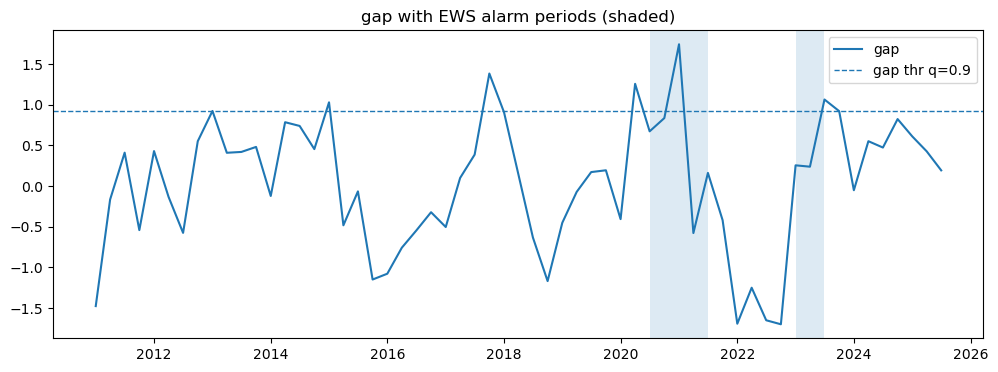

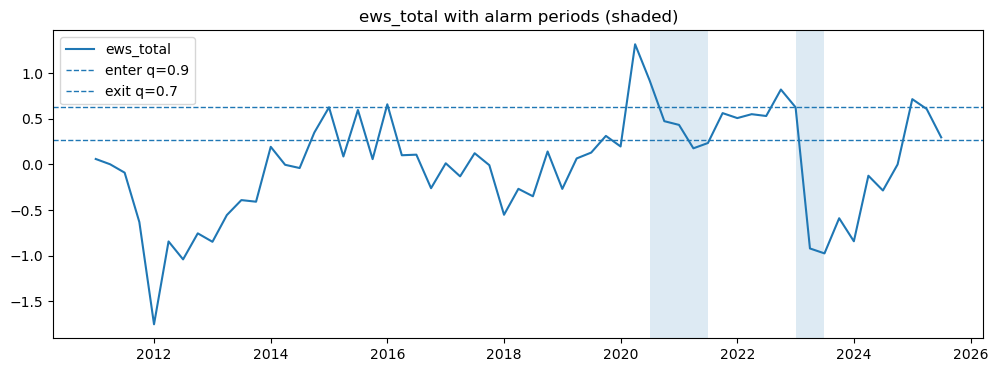

In [16]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(eval_df["date"], eval_df["gap"], label="gap")
ax.axhline(thr_gap, linestyle="--", linewidth=1, label=f"gap thr q={Q}")

for (a,b) in periods:
    ax.axvspan(a, b, alpha=0.15)

ax.set_title("gap with EWS alarm periods (shaded)")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(eval_df["date"], eval_df["ews_total"], label="ews_total")
ax.axhline(thr_enter, linestyle="--", linewidth=1, label=f"enter q={enter_q}")
ax.axhline(thr_exit, linestyle="--", linewidth=1, label=f"exit q={exit_q}")

for (a,b) in periods:
    ax.axvspan(a, b, alpha=0.15)

ax.set_title("ews_total with alarm periods (shaded)")
ax.legend()
plt.show()

In [ ]:
out1 = os.path.join(BASE, "ews_dataset.csv")
out2 = os.path.join(BASE, "ews_alarm_periods.csv")

feat.to_csv(out1, index=False)
alarm_df.to_csv(out2, index=False)

print("saved:", out1)
print("saved:", out2)